## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set Display 
pd.set_option("display.max_columns", None)

## Load The Dataset

In [2]:
df = pd.read_excel(r"C:\Projects\Customer_Churn_Analysis\Data\Telco_customer_churn.xlsx")

# Show Intial Rows
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
# Overview of Dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 33


In [4]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [7]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


## Data Cleansing and Preprocessing

In [8]:
df.drop("CustomerID", axis=1, inplace=True)

In [9]:
df.columns

Index(['Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude',
       'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [10]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [11]:
df["Total Charges"].isnull().sum()

11

In [12]:
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64

## Feature Engineering

In [14]:
df.rename(columns={"Tenure Months": "tenure"}, inplace=True)

In [15]:
bins = [0, 12, 24, 48, 60, 72]
labels = ["0-1 Year", "1-2 Years", "2-4 Years", "4-5 Years", "5-6 Years" ]

df["tenure_band"] = pd.cut(df["tenure"], bins=bins, labels=labels)

In [16]:
df["tenure_band"].value_counts()

tenure_band
0-1 Year     1037
2-4 Years     325
1-2 Years     294
4-5 Years     120
5-6 Years      93
Name: count, dtype: int64

In [17]:
df["contract_group"] = df["Contract"].replace({
    "Month-to-month": "Short Term",
    "One year": "Mid term",
    "Two year": "Long term"
})

In [18]:
df["contract_group"].value_counts()

contract_group
Short Term    1655
Mid term       166
Long term       48
Name: count, dtype: int64

### Segment Monthly Changes

In [19]:
df["charge_band"] = pd.qcut(df["Monthly Charges"], 4, labels=["Low", "Medium", "High", "Very High"])

In [20]:
df["charge_band"].value_counts()

charge_band
Medium       471
Low          468
Very High    467
High         463
Name: count, dtype: int64

In [21]:
churn_rate = df["Churn Value"].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 100.00%


In [22]:
df["Churn Value"].value_counts()

Churn Value
1    1869
Name: count, dtype: int64

In [23]:
df = pd.read_excel(r"C:\Projects\Customer_Churn_Analysis\Data\Telco_customer_churn.xlsx")

In [24]:
df["Churn Value"].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [25]:
df["Churn Value"].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

## Visual Analysis & Business Insights

In [26]:
churn_rate = df["Churn Value"].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


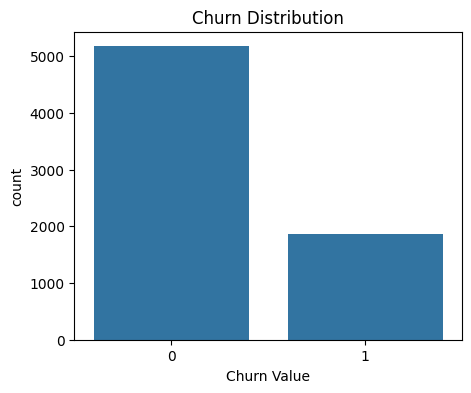

In [27]:
plt.figure(figsize=(5,4))
sns.countplot(x="Churn Value", data=df)
plt.title("Churn Distribution")
plt.show()

## Churn by Contract Type

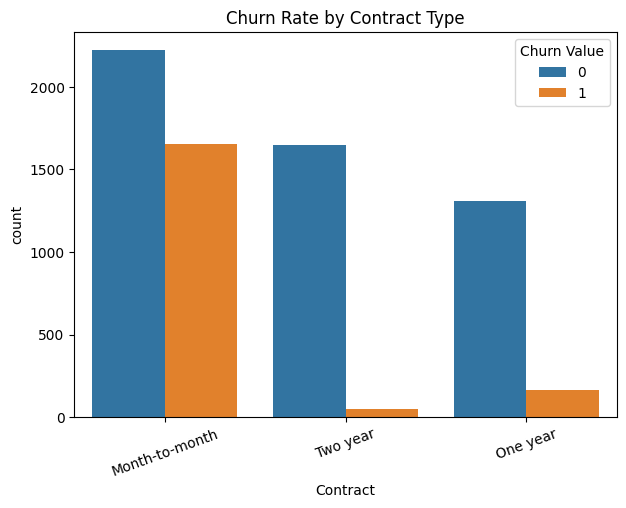

In [28]:
plt.figure(figsize=(7,5))
sns.countplot(x="Contract", hue="Churn Value", data=df)
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=20)
plt.show()

In [29]:
df.groupby("Contract")["Churn Value"].mean() * 100

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64

## Churn By Tenure Band

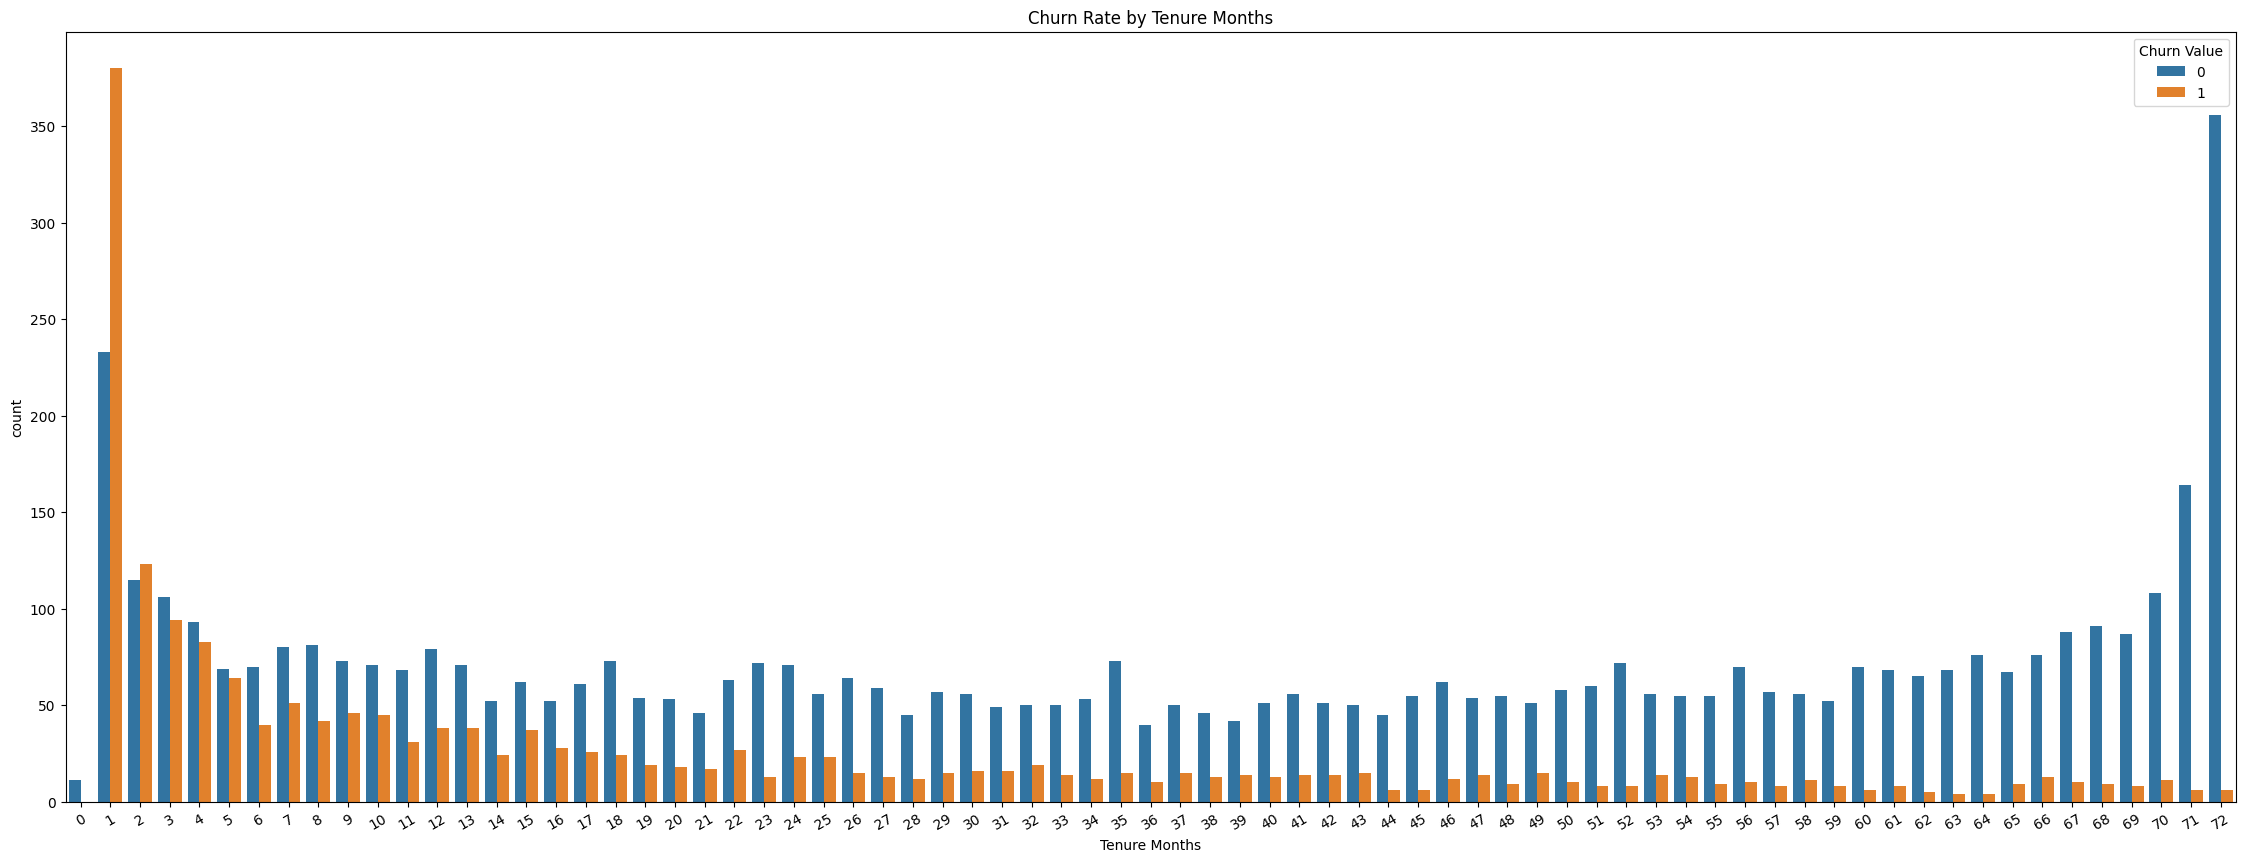

In [30]:
plt.figure(figsize=(28,10))
sns.countplot(x="Tenure Months", hue="Churn Value", data=df)
plt.title("Churn Rate by Tenure Months")
plt.xticks(rotation=30)
plt.show()

## Chrun Rates by Monthly Charges

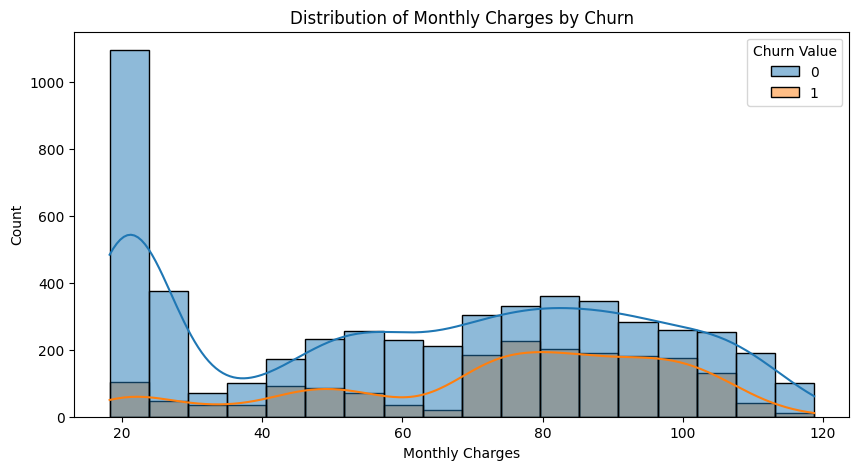

In [31]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Monthly Charges", hue="Churn Value", kde=True)
plt.title("Distribution of Monthly Charges by Churn")
plt.show()

In [32]:
df.groupby("Monthly Charges")["Churn Value"].mean() * 100

Monthly Charges
18.25       0.0
18.40       0.0
18.55       0.0
18.70       0.0
18.75       0.0
          ...  
118.20      0.0
118.35    100.0
118.60      0.0
118.65      0.0
118.75      0.0
Name: Churn Value, Length: 1585, dtype: float64

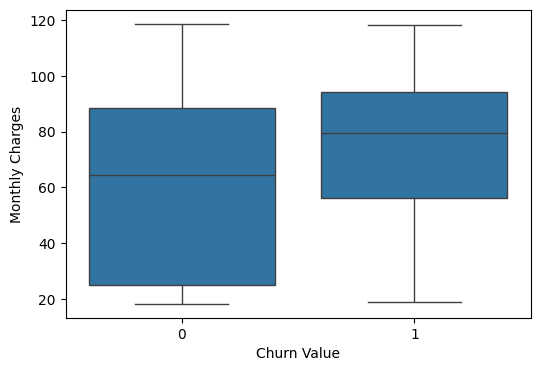

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn Value", y="Monthly Charges", data=df)
plt.show()

## Correlation Heatmap

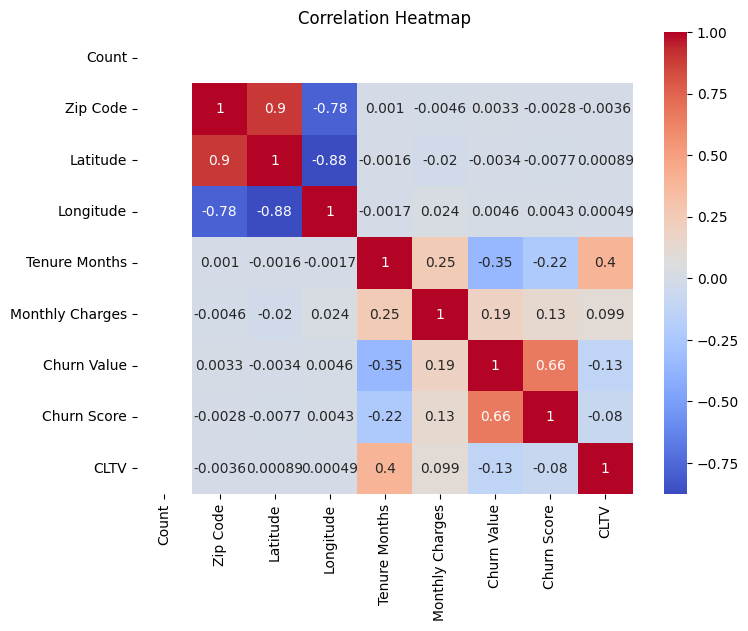

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Churn by Contract (PERCENTAGE, not count)

In [35]:
contract_churn = df.groupby("Contract")["Churn Value"].mean() * 100
print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64


## Early Churn (Your 38% Insight — VERY IMPORTANT)

In [36]:
early_churn = df[
    (df["Churn Value"] == 1) &
    (df["Contract"] == "Month-to-month") &
    (df["Tenure Months"] < 3)
]

total_churn = df[df["Churn Value"] == 1]

percent = (len(early_churn) / len(total_churn)) * 100
print(f"Early churn %: {percent:.2f}%")

Early churn %: 26.81%


## Churn by Tenure Band (Strong Insight)

In [44]:
df.rename(columns={"Tenure Months": "tenure"}, inplace=True)

In [45]:
bins = [0, 12, 24, 48, 60, 72]
labels = ["0-1 Year", "1-2 Years", "2-4 Years", "4-5 Years", "5-6 Years"]

df["tenure_band"] = pd.cut(df["tenure"], bins=bins, labels=labels)

In [46]:
df[["tenure", "tenure_band"]].head()

,tenure,tenure_band
0,2,0-1 Year
1,2,0-1 Year
2,8,0-1 Year
3,28,2-4 Years
4,49,4-5 Years


In [54]:
df.groupby("tenure_band", observed=False)["Churn Value"].mean() * 100
df.groupby("charge_band", observed=False)["Churn Value"].mean() * 100

charge_band
Low          11.237230
Medium       24.575311
High         37.507114
Very High    32.878271
Name: Churn Value, dtype: float64

In [49]:
df["charge_band"] = pd.qcut(
    df["Monthly Charges"],
    4,
    labels=["Low", "Medium", "High", "Very High"]
)

In [59]:
df.groupby("tenure_band", observed=False)["Churn Value"].mean() * 100

tenure_band
0-1 Year     47.678161
1-2 Years    28.710938
2-4 Years    20.388959
4-5 Years    14.423077
5-6 Years     6.609808
Name: Churn Value, dtype: float64

In [52]:
df.groupby("Payment Method")["Churn Value"].mean() * 100

Payment Method
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn Value, dtype: float64

## 🔍 Key Business Insights

- Customers on month-to-month contracts exhibit the highest churn rate (~43%), indicating lack of long-term commitment as a key risk factor.  
- New customers (0–1 year) show the highest churn (~48%), confirming that churn is concentrated in early lifecycle stages.  
- Approximately 27% of churned users are early-stage (<3 months) month-to-month customers, highlighting onboarding and engagement gaps.  
- Higher monthly charges correlate with increased churn, though impact is moderate compared to contract and tenure.  
- Customers using electronic check show significantly higher churn (~45%), suggesting payment behavior as a strong churn indicator.  

## 🚀 Business Recommendations

- Introduce early engagement programs within the first 90 days to reduce initial churn.  
- Encourage customers to shift to long-term contracts through discounts or incentives.  
- Improve value proposition for high-paying customers to reduce price-driven churn.  
- Promote automatic payment methods to reduce friction and improve retention.  